<div style="background: rgba(30, 34, 42, 0.4); border: 1px solid #475569; padding: 40px 36px; border-radius: 12px; margin-bottom: 18px; box-shadow: inset 0 1px 1px rgba(255,255,255,0.02);">
  <h1 style="color: #cbd5e1; font-size: 1.9em; font-weight: bold; margin: 0 0 12px 0; letter-spacing: -0.5px;">
    🦠 실시간 독감 위험지수 예측 모델링
  </h1>
  <h2 style="color: #94a3b8; font-size: 1.1em; font-weight: normal; margin: 0 0 24px 0;">
    Search Trend + Weather Data &nbsp;·&nbsp; LSTM vs TFT Benchmarking
  </h2>
  <div style="display: flex; gap: 8px; flex-wrap: wrap;">
    <span style="background: rgba(255,255,255,0.04); border: 1px solid #475569; color: #94a3b8; padding: 5px 14px; border-radius: 6px; font-size: 0.85em;">Data Ablation Study</span>
    <span style="background: rgba(255,255,255,0.04); border: 1px solid #475569; color: #94a3b8; padding: 5px 14px; border-radius: 6px; font-size: 0.85em;">LSTM · TFT</span>
    <span style="background: rgba(255,255,255,0.04); border: 1px solid #475569; color: #94a3b8; padding: 5px 14px; border-radius: 6px; font-size: 0.85em;">SHAP · Variable Importance</span>
    <span style="background: rgba(255,255,255,0.04); border: 1px solid #475569; color: #94a3b8; padding: 5px 14px; border-radius: 6px; font-size: 0.85em;">Medical AI</span>
  </div>
</div>

---
## 📋 목차 (Table of Contents)

| # | 섹션 | 핵심 내용 |
|---|------|-----------|
| 1 | **Problem Definition** | 질병청 데이터 7일 시차 문제 · 실시간 데이터 활용 배경 |
| 2 | **Data Engineering** | 이동평균 · COVID 구간 처리 · 키워드 군집화 · 기상 결측치 보정 |
| 3 | **Model Benchmarking** | LSTM 구조 · TFT VSN + Attention · Direct vs Recursive Forecast |
| 4 | **Evaluation** | RMSE·MAE·MAPE·R² · 유행기/정점기 구간 평가 · SHAP · TFT Variable Importance |
| 5 | **Limitations** | 표본·도메인 시프트·데이터 누수·SHAP 자기충돌 등 5대 한계 |
| 6 | **Conclusion** | 의료 현장 활용 · 대국민 서비스 · 향후 개선 방향 |

---

# Section 1 · Problem Definition
## 왜 실시간 독감 예측이 필요한가?

> *"공공 데이터는 정확하지만 느리다. 우리는 그 공백을 메운다."*


<div style="background: rgba(30, 34, 42, 0.4); border-left: 4px solid #64748b; padding: 18px 22px; border-radius: 8px; margin: 16px 0; color: #94a3b8; box-shadow: inset 0 1px 1px rgba(255,255,255,0.02);">
  <h4 style="color: #cbd5e1; margin: 0 0 12px 0; font-size: 1.05em; font-weight: bold; letter-spacing: -0.3px;">📌 핵심 용어 정의: ILI (Influenza-Like Illness, 인플루엔자 의사환자율)</h4>
  <p style="margin: 0 0 10px 0; line-height: 1.6;">
  ILI(인플루엔자 의사환자율)는 외래 환자 1,000명당 인플루엔자 증상을 보인 환자 수입니다.<br>
  진단 기준: 38℃ 이상 발열 + 기침 또는 인후통 동반.
  </p>
  <table style="width:100%; border-collapse:collapse; font-size:0.92em; margin-top:4px;">
    <tr style="background: rgba(255, 255, 255, 0.02);">
      <td style="padding:8px 12px; font-weight:bold; width:22%; color: #cbd5e1;">산출 기관</td>
      <td style="padding:8px 12px; color: #94a3b8;">질병관리청(KDCA) — 전국 약 200개 표본 감시 의료기관 집계</td>
    </tr>
    <tr>
      <td style="padding:8px 12px; font-weight:bold; color: #cbd5e1;">집계 단위</td>
      <td style="padding:8px 12px; color: #94a3b8;">주(Week) 단위 / 독감 절기(36주차 ~ 익년 35주차, 총 52주) 기준</td>
    </tr>
    <tr style="background: rgba(255, 255, 255, 0.02);">
      <td style="padding:8px 12px; font-weight:bold; color: #cbd5e1;">유행 기준치</td>
      <td style="padding:8px 12px; color: #94a3b8;">ILI &ge; 9.1 → 유행기 &nbsp;/&nbsp; ILI &ge; 45.5 → 정점기</td>
    </tr>
    <tr>
      <td style="padding:8px 12px; font-weight:bold; color: #cbd5e1;">구조적 한계</td>
      <td style="padding:8px 12px; color: #94a3b8;">실제 진료 발생 후 약 7일 시차를 두고 공표 → 선제 대응 어려움</td>
    </tr>
  </table>
</div>

### 1.1 질병관리청(KDCA) 데이터의 구조적 한계

질병관리청은 매주 전국 의료기관의 **인플루엔자 의사환자율(ILI, Influenza-Like Illness)**을 수집·공표합니다.  
그러나 **수집 → 검수 → 집계 → 발표** 과정을 거쳐 실제 진료 시점으로부터 약 **7일의 시차**가 발생합니다.

```
[ 실제 진료 발생 ] ──── 7일 시차 ────▶ [ KDCA 공표 ]
        ↑                                      ↑
   우리가 필요한 시점              데이터가 도착하는 시점
```

| 문제 | 영향 |
|------|------|
| **후행성 (7일 시차)** | 유행 정점 도달 후에야 경보 발령 가능 |
| **주별 단위 집계** | 일별 급변 상황 포착 불가 |
| **절기 기반 발표** | 36주차(9월)~35주차(다음해), 총 52주를 1개 단위로 관리 |

### 1.2 해결 방향: 실시간 대리 지표 활용

- 🔍 **네이버 검색 트렌드**: 증상 발현 즉시 검색 → ILI 공표보다 **1~2주 선행**
- 🌡️ **기상 데이터 (기온/습도)**: 바이러스 생존율과 직결 → 검색 노이즈 **필터링 역할**

### 1.3 프로젝트 목표

$$\hat{y}_{t+1} = f\!\left(\text{ILI}_t,\ \Delta\text{ILI}_t,\ \text{Search}_t,\ \text{Weather}_t,\ \sin/\cos_t\right)$$

> 위 함수 $f$를 **LSTM** 및 **TFT** 모델로 학습하고, 데이터 조합별·예측 방식별 성능 향상을 **정량적으로 증명**합니다.

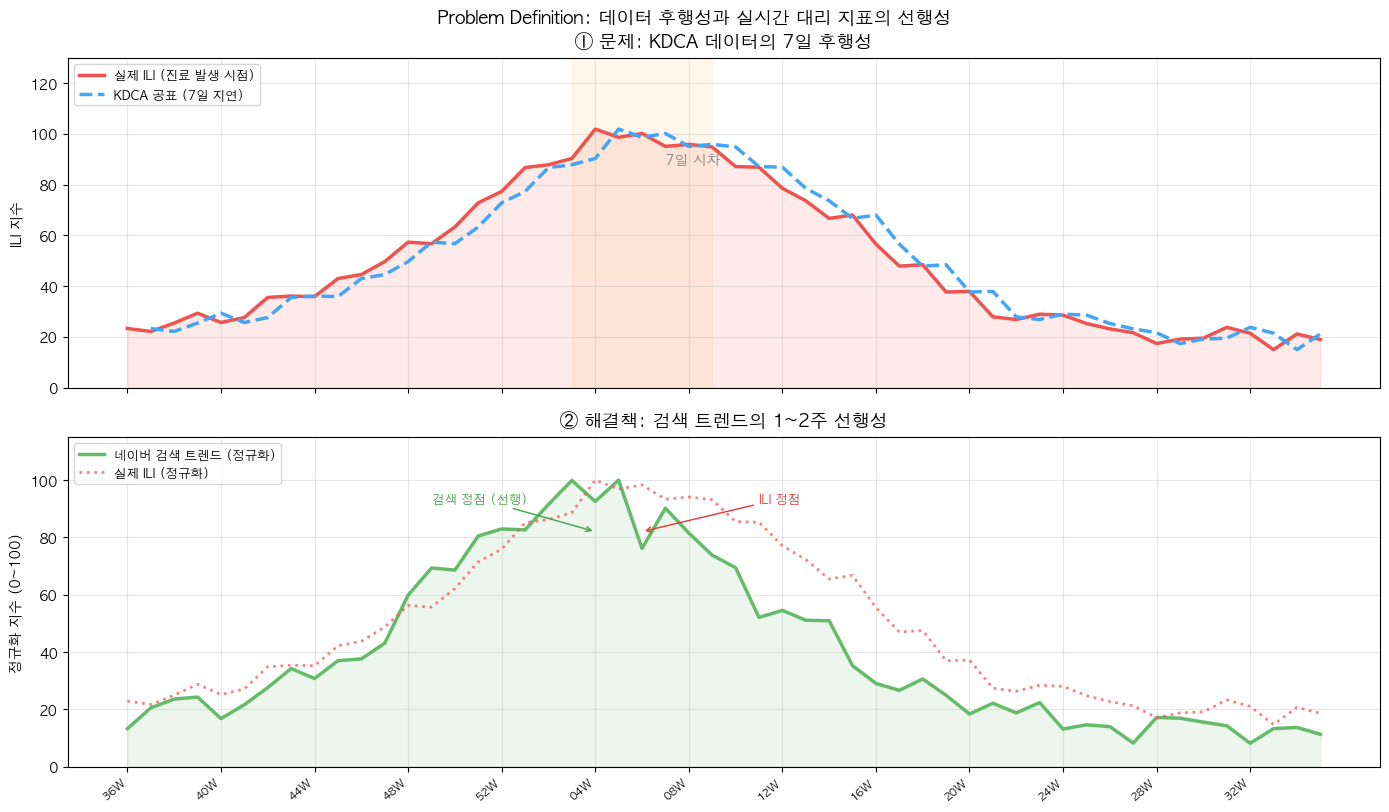

In [13]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False 

weeks = np.arange(52)
week_labels = [f"{w:02d}W" for w in range(36, 53)] + [f"{w:02d}W" for w in range(1, 36)]

np.random.seed(42)
ili_actual = 20 + 80 * np.exp(-0.5 * ((weeks - 22) / 8) ** 2) + np.random.normal(0, 3, 52)
ili_actual = np.clip(ili_actual, 10, 110)
kdca_pub = np.concatenate([[np.nan], ili_actual[:-1]])
search = 15 + 75 * np.exp(-0.5 * ((weeks - 20) / 7) ** 2) + np.random.normal(0, 5, 52)
search = np.clip(search, 5, 100)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1 = axes[0]
ax1.fill_between(weeks, ili_actual, alpha=0.12, color='#ef5350')
ax1.plot(weeks, ili_actual, color='#ef5350', lw=2.5, label='실제 ILI (진료 발생 시점)')
ax1.plot(weeks, kdca_pub, color='#42a5f5', lw=2.5, ls='--', label='KDCA 공표 (7일 지연)')
ax1.axvspan(19, 25, alpha=0.08, color='orange')
ax1.annotate('7일 시차', xy=(23, 88), fontsize=10, color='gray')
ax1.set_ylabel('ILI 지수'); ax1.set_ylim(0, 130)
ax1.set_title('① 문제: KDCA 데이터의 7일 후행성', fontsize=13, fontweight='bold', pad=8)
ax1.legend(loc='upper left', fontsize=9); ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.fill_between(weeks, search / search.max() * 100, alpha=0.12, color='#66bb6a')
ax2.plot(weeks, search / search.max() * 100, color='#66bb6a', lw=2.5, label='네이버 검색 트렌드 (정규화)')
ax2.plot(weeks, ili_actual / ili_actual.max() * 100, color='#ef5350', lw=2, ls=':', alpha=0.7, label='실제 ILI (정규화)')
ax2.annotate('검색 정점 (선행)', xy=(20, 82), fontsize=9, color='#43a047',
             xytext=(13, 92), arrowprops=dict(arrowstyle='->', color='#43a047'))
ax2.annotate('ILI 정점', xy=(22, 82), fontsize=9, color='#e53935',
             xytext=(27, 92), arrowprops=dict(arrowstyle='->', color='#e53935'))
ax2.set_ylabel('정규화 지수 (0~100)'); ax2.set_ylim(0, 115)
ax2.set_title('② 해결책: 검색 트렌드의 1~2주 선행성', fontsize=13, fontweight='bold', pad=8)
ax2.legend(loc='upper left', fontsize=9); ax2.grid(True, alpha=0.3)

tick_pos = np.arange(0, 52, 4)
ax2.set_xticks(tick_pos)
ax2.set_xticklabels([week_labels[i] for i in tick_pos], rotation=40, ha='right', fontsize=8)
plt.tight_layout()
plt.suptitle('Problem Definition: 데이터 후행성과 실시간 대리 지표의 선행성',
             fontsize=13, fontweight='bold', y=1.01)
plt.show()

---
# 🔧 Section 2 · Data Engineering
## 데이터를 어떻게 정제하고 설계했는가?

> *"좋은 모델보다 좋은 데이터가 우선이다."*

### 2.1 독감 절기(Season) 기반 데이터 구조

독감은 달력 연도가 아닌 **절기(Season)** 단위로 유행합니다.  
모든 데이터를 **36주차~다음해 35주차(총 52주)** 단위로 정렬하여 두 모델 모두 동일하게 적용합니다.

| 데이터셋 | 활용 절기 | 비고 |
|----------|-----------|------|
| **학습 (Train)** | 2014-15, 2015-16, 2016-17, 2017-18 | 4개 절기 (LSTM·TFT 공통) |
| **검증 (Validation)** | 2018-19 | 1개 절기 |
| **테스트 (Test)** | 2024-25 | 최신 절기 |
| **❌ 제외** | 2020-22 | COVID-19 데이터 왜곡 구간 |

### 2.2 COVID-19 구간 제외

2020~2022년은 방역 조치로 ILI가 **비정상적으로 낮게** 기록되어 일반화 성능을 저하시킵니다.

$$\text{Data}_{\text{train}} = \{\text{Season}_i \mid i \notin [2020\text{-}21,\ 2021\text{-}22,\ 2022\text{-}23]\}$$

### 2.3 주기성 인코딩: sin/cos 변환

$$\text{sin}_t = \sin\!\left(\frac{2\pi t}{52}\right), \quad \cos_t = \cos\!\left(\frac{2\pi t}{52}\right)$$

> sin·cos 두 값을 함께 사용해야 원형 주기의 **2D 공간 유일 위치**로 표현 가능. (sin만 사용 시 0°=180° 혼동)

### 2.4 7일 이동평균 (Moving Average)

$$\text{MA}_7(t) = \frac{1}{7}\sum_{k=0}^{6} x_{t-k}$$

검색 트렌드의 주말·공휴일 효과(요일별 편차)를 제거합니다.

### 2.5 기상 결측치 보정 (TFT 코드 기반)

기상 데이터의 결측치는 **주차(week)별 평균값으로 1차 보정**하고, 남은 결측치는 전체 평균으로 채웁니다.

```python
# fill_weather_missing()
for col in weather_cols:
    week_mean = df.groupby('주차')[col].transform('mean')  # 주차별 평균
    df[col] = df[col].fillna(week_mean)                   # 1차: 주차 평균
    df[col] = df[col].fillna(df[col].mean())              # 2차: 전체 평균
```

### 2.6 검색 키워드 수집 및 상관계수 기반 필터링 (검색데이터 코드 기반)

키워드 선별은 임의의 수동 가중치가 아니라, **실제 ILI와의 상관관계를 측정해 데이터 기반으로 필터링**합니다.

**① 네이버 데이터랩 API로 주간 검색량 수집**

```python
# 네이버 데이터랩 검색 트렌드 API
url = 'https://openapi.naver.com/v1/datalab/search'
body = {
    'startDate': start_dt, 'endDate': end_dt,
    'timeUnit': 'week',                      # 주간 단위
    'keywordGroups': [{'groupName': g, 'keywords': kw_list}],
    'device': '', 'ages': [], 'gender': '',  # 전체 기기·연령·성별
}
# 응답의 'ratio' = 기간 내 최대 검색량 대비 0~100 상대값
```

키워드를 **그룹(group) 단위**로 묶어 호출하고, 각 그룹의 주간 상대 검색량(ratio)을 추출합니다.

**② ILI와의 피어슨 상관계수(Pearson r) 계산**

$$r = \frac{\sum_{i}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_i (x_i-\bar{x})^2}\,\sqrt{\sum_i (y_i-\bar{y})^2}}$$

여기서 $x$는 키워드 검색량(ratio), $y$는 실제 ILI 값입니다. 각 키워드 그룹별로 $r$을 산출해 **ILI 흐름과의 유사도 순위**를 매깁니다.

```python
from scipy.stats import pearsonr
for column in pivot_df.columns:               # 키워드 그룹별
    corr, _ = pearsonr(pivot_df[column], current_ili)
    rankings.append({'Keyword': column, 'Correlation': corr})
rank_df = pd.DataFrame(rankings).sort_values('Correlation', ascending=False)
```

**③ 상관계수 상위 키워드만 모델 입력으로 선별**

> ILI와 상관계수가 높은 **상위 키워드(Top-N)** 만 선별하여 저장(`top_5_search_trends.csv`)합니다.  
> 미디어 노이즈성 키워드(상관 낮음)는 자연스럽게 제외되어, **노이즈를 데이터 기반으로 통제**합니다.


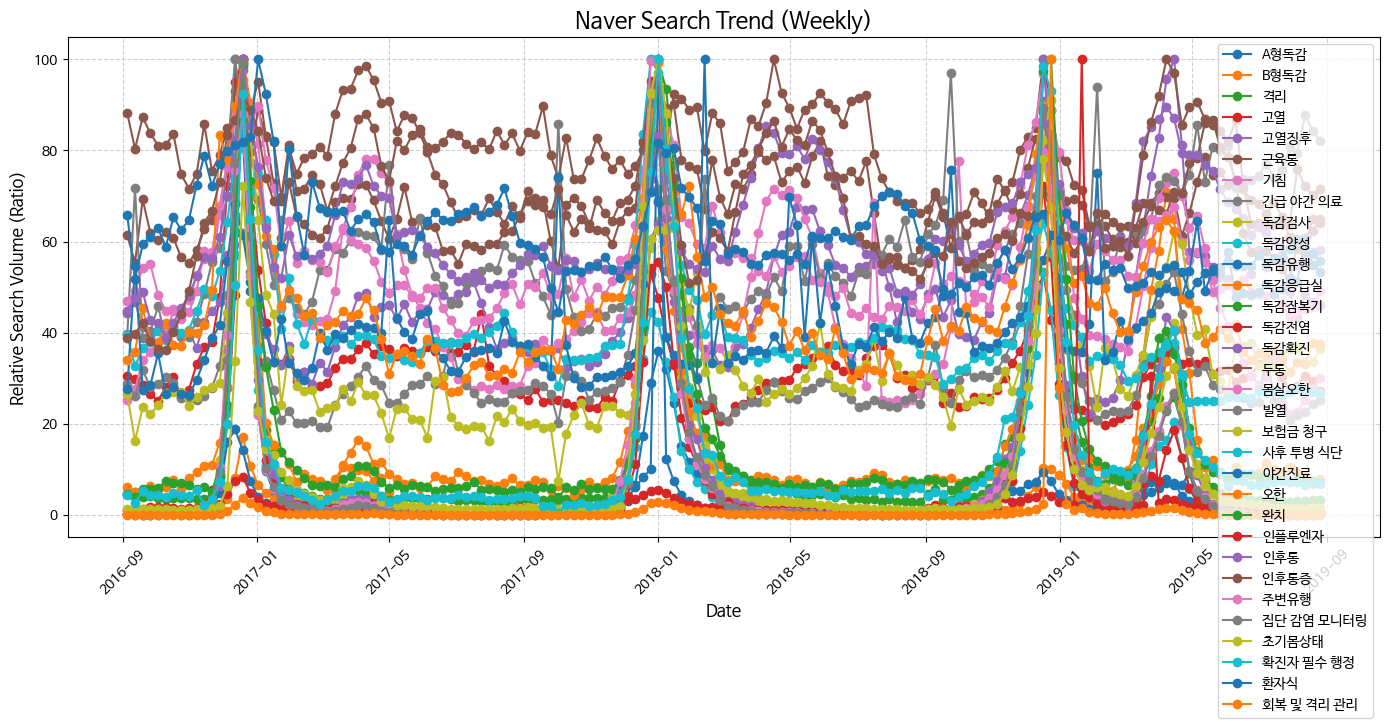
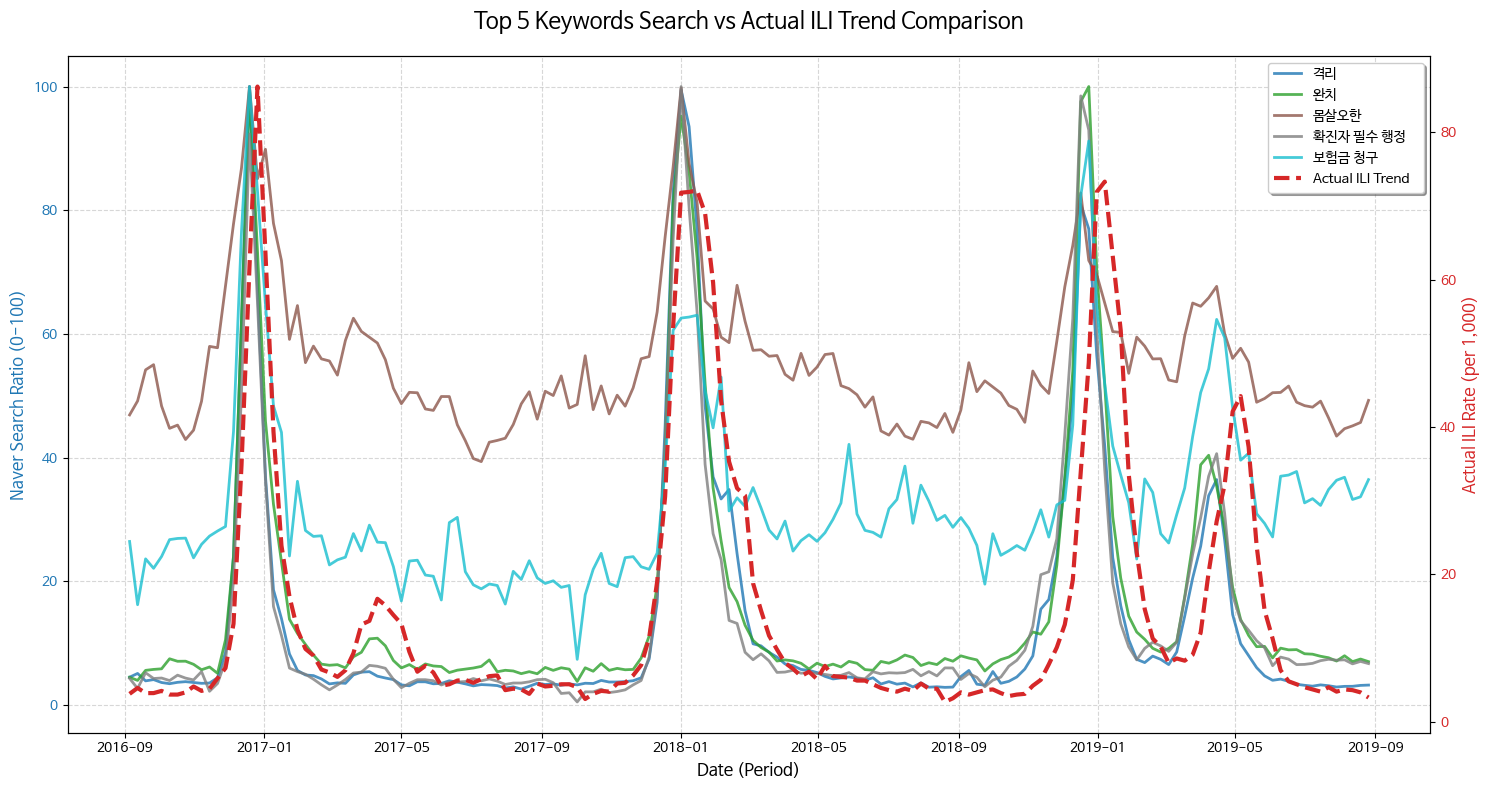


### 2.7 ΔILI 기울기 특성 (두 모델 공통)

$$\Delta\text{ILI}_t = \text{ILI}_{t-1} - \text{ILI}_{t-2}$$

> 이번 주 입력 기준, **직전 주의 변화량**을 추가 특성으로 활용. 두 모델 모두 이 특성 추가 시 MAE가 개선되었습니다.

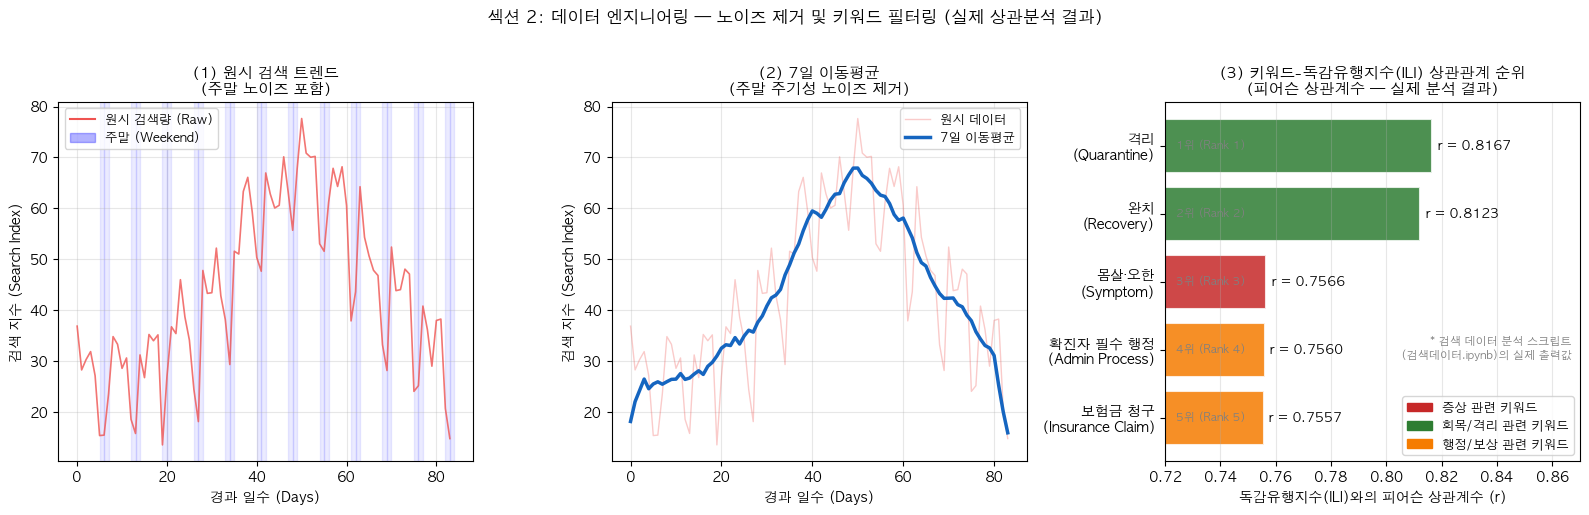

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(7)
days = np.arange(84)
base = 30 + 40 * np.exp(-0.5 * ((days - 50) / 15) ** 2)
weekend_mask = (days % 7 == 5) | (days % 7 == 6)
noise = np.random.normal(0, 4, 84)
noise[weekend_mask] -= 15
raw = np.clip(base + noise, 5, 100)
ma7 = np.convolve(raw, np.ones(7)/7, mode='same')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── 1. 원시 검색량 (주말 노이즈) ──
ax = axes[0]
ax.plot(days, raw, color='#ef5350', lw=1.2, alpha=0.8)
for d in days[weekend_mask]:
    ax.axvspan(d, d+1, alpha=0.08, color='blue')
ax.legend(handles=[
    plt.Line2D([0],[0], color='#ef5350', lw=1.5, label='원시 검색량 (Raw)'),
    patches.Patch(alpha=0.3, color='blue', label='주말 (Weekend)'),
], fontsize=9)
ax.set_title('(1) 원시 검색 트렌드\n(주말 노이즈 포함)', fontsize=11, fontweight='bold')
ax.set_ylabel('검색 지수 (Search Index)'); ax.set_xlabel('경과 일수 (Days)')
ax.grid(True, alpha=0.3)

# ── 2. 7일 이동평균 ──
ax = axes[1]
ax.plot(days, raw, color='#ef5350', lw=1, alpha=0.3, label='원시 데이터')
ax.plot(days, ma7, color='#1565c0', lw=2.5, label='7일 이동평균')
ax.set_title('(2) 7일 이동평균\n(주말 주기성 노이즈 제거)', fontsize=11, fontweight='bold')
ax.set_ylabel('검색 지수 (Search Index)'); ax.set_xlabel('경과 일수 (Days)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── 3. 실제 피어슨 상관계수 결과 ──
ax = axes[2]

# 순위별 실제 키워드 명칭 한글화 (Rank 1~5 오름차순 정렬)
keywords = [
    '보험금 청구\n(Insurance Claim)',      # Rank 5
    '확진자 필수 행정\n(Admin Process)',    # Rank 4
    '몸살·오한\n(Symptom)',                 # Rank 3
    '완치\n(Recovery)',                     # Rank 2
    '격리\n(Quarantine)',                   # Rank 1
]
corr_vals = [0.755692, 0.755971, 0.756586, 0.812291, 0.816665]

# 역할별 색상 구분 (증상: 빨강, 회복/격리: 초록, 행정/보상: 주황)
bar_colors = ['#f57c00', '#f57c00', '#c62828', '#2e7d32', '#2e7d32']
bars = ax.barh(keywords, corr_vals,
               color=bar_colors, alpha=0.85, edgecolor='white', linewidth=1.5)

for bar, v in zip(bars, corr_vals):
    ax.text(v + 0.002, bar.get_y() + bar.get_height()/2,
            f'r = {v:.4f}', va='center', fontsize=9.5, fontweight='bold')

# 순위 라벨 표시
for i, rank in enumerate(['5위 (Rank 5)','4위 (Rank 4)','3위 (Rank 3)','2위 (Rank 2)','1위 (Rank 1)']):
    ax.text(0.724, i, rank, va='center', fontsize=8, color='gray')

ax.set_xlim(0.72, 0.87)
ax.set_title('(3) 키워드-독감유행지수(ILI) 상관관계 순위\n(피어슨 상관계수 — 실제 분석 결과)', fontsize=11, fontweight='bold')
ax.set_xlabel('독감유행지수(ILI)와의 피어슨 상관계수 (r)'); ax.grid(True, alpha=0.3, axis='x')

legend_patches = [
    patches.Patch(color='#c62828', label='증상 관련 키워드'),
    patches.Patch(color='#2e7d32', label='회복/격리 관련 키워드'),
    patches.Patch(color='#f57c00', label='행정/보상 관련 키워드'),
]
ax.legend(handles=legend_patches, fontsize=9, loc='lower right')
ax.text(0.98, 0.28, '* 검색 데이터 분석 스크립트\n  (검색데이터.ipynb)의 실제 출력값',
        transform=ax.transAxes, fontsize=8, color='gray',
        ha='right', va='bottom', style='italic')

plt.suptitle(
    '섹션 2: 데이터 엔지니어링 — 노이즈 제거 및 키워드 필터링 (실제 상관분석 결과)',
    fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
# 🧠 Section 3 · Model Benchmarking
## LSTM vs TFT: 구조와 실험 설계 비교

> *"모델의 선택은 데이터의 구조에 대한 가설이다."*

### 3.1 Model A: LSTM (Long Short-Term Memory)

**3개의 게이트**를 통해 장기 의존성을 학습합니다.

$$f_t = \sigma(W_f[h_{t-1},x_t]+b_f) \quad \text{(Forget Gate)}$$
$$i_t = \sigma(W_i[h_{t-1},x_t]+b_i),\quad \tilde{C}_t = \tanh(W_C[h_{t-1},x_t]+b_C) \quad \text{(Input Gate)}$$
$$o_t = \sigma(W_o[h_{t-1},x_t]+b_o),\quad h_t = o_t \odot \tanh(C_t) \quad \text{(Output Gate)}$$

```python
# LSTM 팀원 실제 설정 (수동 그리드 실험으로 결정)
Config(hidden_size=64, num_layers=1, dropout=0.0,
       batch_size=1, lr=0.001, epochs=800, patience=30, grad_clip=1.0)
```

**LSTM 실험 구조**: ILI 단독 → +ΔILI → +Weather → +Keyword (순차 Ablation)
**하이퍼파라미터 탐색**: TFT는 Optuna 자동 탐색, **LSTM은 팀원이 직접 그리드 실험으로 비교**해 최적값 결정 → 자세한 결과는 3.1.1

---

### 3.2 Model B: TFT (Temporal Fusion Transformer)

```python
# TFT 팀원 실제 설정 (Optuna 탐색 공간)
MODEL_CONFIG = dict(
    max_encoder_length  = 8,    # Optuna: [4, 8, 12, 16, 24]
    max_prediction_length = 1,
    learning_rate       = 0.0005,  # Optuna: [1e-4, 3e-3] log-scale
    hidden_size         = 20,      # Optuna: [8, 16, 20, 32]
    attention_head_size = 2,       # Optuna: [1, 2, 4]
    hidden_continuous_size = 20,   # Optuna: [4, 8, 12, 16, 20]
    dropout             = 0.15,    # Optuna: [0.05, 0.15]
)
```

#### 핵심 메커니즘 1: Variable Selection Network (VSN)

$$\mathbf{v}_t = \text{softmax}\!\left(\text{GRN}(\mathbf{x}_t)\right) \odot \mathbf{x}_t$$

→ 뉴스성 검색 급증 같은 노이즈 변수에 낮은 가중치를 **자동으로** 부여

#### 핵심 메커니즘 2: Multi-Head Attention

$$\text{Attention}(Q,K,V) = \text{softmax}\!\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

→ 어느 과거 주차가 중요한지 **Attention Weight 시각화** 가능

---

### 3.3 TFT 고유 실험: 예측 방식 비교

| 방식 | 설명 | 장점 | 단점 |
|------|------|------|------|
| **Direct Forecast** | 2024-25 전체를 한 번에 예측 (이전 주 실제 ILI 입력 가능) | 정확도 높음 | 실시간 적용 한계 |
| **Recursive Forecast** | 예측값을 다음 주 ILI 입력으로 재사용 | 완전한 미래 예측 | 오차 누적 위험 |

### 3.4 TFT 고유 기능: VSN 기반 Feature Selection

1차 학습 후 **Variable Selection 중요도 Top-K 특성만** 선별하여 2차 재학습:

```python
# 필수 유지 특성 (LSTM과 공통)
ESSENTIAL_FEATURES = ['time_idx', 'season_week_idx', 'week_sin', 'week_cos', 'ili_diff_1']
TOP_K_FEATURES = 12  # VSN 중요도 상위 12개 + 필수 특성
```

### 3.5 모델 비교 요약

| 항목 | LSTM | TFT |
|------|------|-----|
| **노이즈 필터링** | 수동 (키워드 가중치 설계) | **자동** (VSN) |
| **예측 방식** | One-step Direct | Direct + **Recursive** 비교 |
| **특성 선택** | 수동 Ablation (실험 1~6) | **자동** (VSN 중요도 Top-K) |
| **해석 가능성** | SHAP (사후 분석) | **Attention Weight** (내장) |
| **장기 예측** | ⚠️ Rollout 오차 | ✅ Recursive 지원 |
| **하이퍼파라미터** | 수동 Grid Search | **Optuna 자동 탐색** |

### 3.1.1 LSTM 하이퍼파라미터 실험 결과 (요약)

`batch_size` → `hidden_size` → `num_layers + dropout` → `learning_rate` 순서로 한 변수씩 바꿔가며 검증 지표를 비교했습니다.

| 파라미터 | 비교한 값 | **채택** | 메모 |
|---|---|---|---|
| `batch_size` | 4 / 2 / 1 | **1** | 학습 절기가 4개로 적어 배치 작을수록 일반화↑ |
| `hidden_size` | 16 / 32 / 64 / 128 | **64** | 16은 용량 부족, 128은 과적합 |
| `num_layers + dropout` | 1+0 / 2+(0.1~0.5) | **1 + 0** | 2층이 지표는 좋지만 특성 추가 시 키워드 구간 오버피팅 |
| `learning_rate` | 0.001 / 0.0005 | **0.001** | 0.0005는 학습은 안정적이나 지표 악화 |

> **결론**: 단일 지표만 보면 `2층 + dropout 0.3`이 우세하지만, **Weather·Keyword 특성을 추가했을 때 1층이 더 안정적**이라 1층을 최종 채택.
> TFT(Optuna 자동) ↔ LSTM(수동 실험)의 차이를 그대로 보여주는 과정.


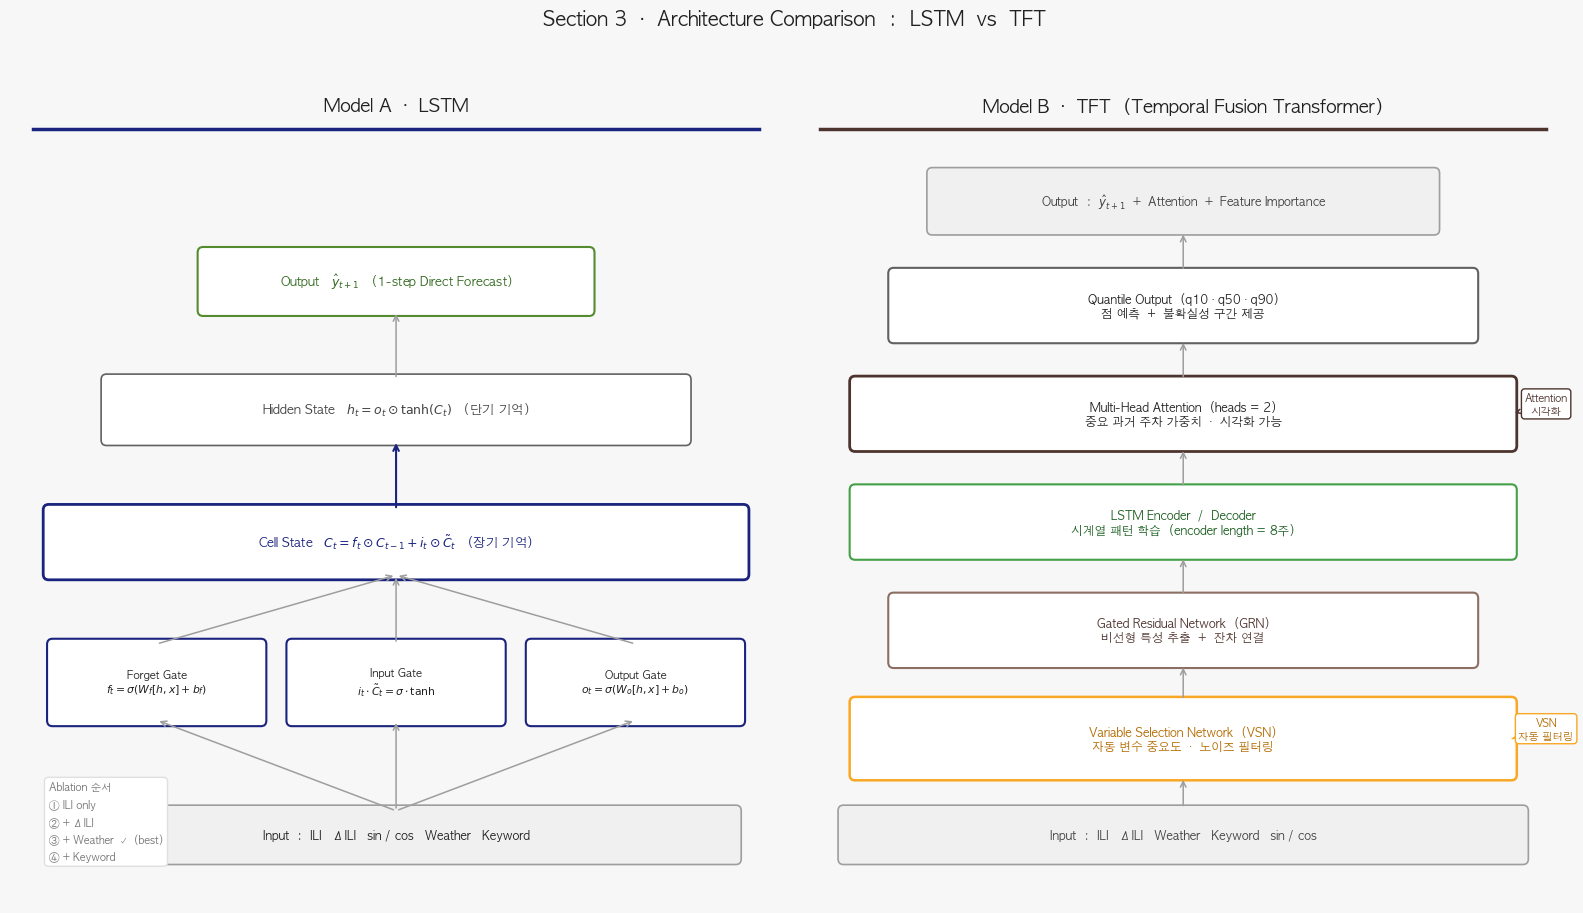

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

LSTM_C = '#1a237e'
TFT_C  = '#4e342e'

def box(ax, x, y, w, h, txt, fc='#ffffff', ec='#bdbdbd', tc='#212121', fs=8.5, lw=1.2, bold=False):
    ax.add_patch(FancyBboxPatch((x-w/2, y-h/2), w, h,
                 boxstyle='round,pad=0.07', fc=fc, ec=ec, lw=lw, zorder=3))
    ax.text(x, y, txt, ha='center', va='center', fontsize=fs,
            color=tc, fontweight='bold' if bold else 'normal',
            multialignment='center', zorder=4)

def arr(ax, x1, y1, x2, y2, c='#9e9e9e', lw=1.1):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=c, lw=lw))

fig, axes = plt.subplots(1, 2, figsize=(16, 9), facecolor='#f7f7f7')
fig.patch.set_facecolor('#f7f7f7')

# ── LSTM ──
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 10.2); ax.axis('off')
ax.set_facecolor('#f7f7f7')
ax.text(5, 10.05, 'Model A  ·  LSTM', ha='center', va='top',
        fontsize=13, fontweight='bold', color='#212121')
ax.plot([0.3, 9.7], [9.65, 9.65], color=LSTM_C, lw=2.5)

box(ax, 5, 0.85, 8.8, 0.60,
    'Input  :  ILI   ΔILI   sin / cos   Weather   Keyword',
    fc='#f0f0f0', ec='#9e9e9e', fs=8.5)

for gx, glbl, eq in [
    (1.9, 'Forget Gate', '$f_t = \\sigma(W_f[h,x]+b_f)$'),
    (5.0, 'Input Gate',  '$i_t \\cdot \\tilde{C}_t = \\sigma \\cdot \\tanh$'),
    (8.1, 'Output Gate', '$o_t = \\sigma(W_o[h,x]+b_o)$'),
]:
    box(ax, gx, 2.75, 2.7, 0.95, f'{glbl}\n{eq}',
        fc='#ffffff', ec=LSTM_C, tc='#212121', fs=7.8, lw=1.5)
    arr(ax, 5, 1.15, gx, 2.28)

box(ax, 5, 4.50, 9.0, 0.80,
    'Cell State   $C_t = f_t \\odot C_{t-1} + i_t \\odot \\tilde{C}_t$   (장기 기억)',
    fc='#ffffff', ec=LSTM_C, tc=LSTM_C, fs=9.0, lw=2.0, bold=True)
box(ax, 5, 6.15, 7.5, 0.75,
    'Hidden State   $h_t = o_t \\odot \\tanh(C_t)$   (단기 기억)',
    fc='#ffffff', ec='#616161', tc='#424242', fs=9.0, lw=1.2)
box(ax, 5, 7.75, 5.0, 0.72,
    'Output   $\\hat{y}_{t+1}$   (1-step Direct Forecast)',
    fc='#ffffff', ec='#558b2f', tc='#33691e', fs=9.0, lw=1.5)

for gx in [1.9, 5.0, 8.1]:
    arr(ax, gx, 3.23, 5, 4.09)
arr(ax, 5, 4.90, 5, 5.77, c=LSTM_C, lw=1.5)
arr(ax, 5, 6.53, 5, 7.38)

ax.text(0.05, 0.05,
        'Ablation 순서\n① ILI only\n② + ΔILI\n③ + Weather  ✓  (best)\n④ + Keyword',
        transform=ax.transAxes, fontsize=7.5, color='#757575',
        va='bottom', linespacing=1.7,
        bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='#e0e0e0', lw=1))

# ── TFT ──
ax = axes[1]
ax.set_xlim(0, 10); ax.set_ylim(0, 10.2); ax.axis('off')
ax.set_facecolor('#f7f7f7')
ax.text(5, 10.05, 'Model B  ·  TFT  (Temporal Fusion Transformer)',
        ha='center', va='top', fontsize=13, fontweight='bold', color='#212121')
ax.plot([0.3, 9.7], [9.65, 9.65], color=TFT_C, lw=2.5)

layers = [
    (0.85, 8.8, 0.60, 'Input  :  ILI   ΔILI   Weather   Keyword   sin / cos',
     '#f0f0f0', '#9e9e9e', '#424242', 8.5, 1.2),
    (2.05, 8.5, 0.90, 'Variable Selection Network  (VSN)\n자동 변수 중요도  ·  노이즈 필터링',
     '#ffffff', '#f9a825', '#b26a00', 8.5, 1.8),
    (3.40, 7.5, 0.80, 'Gated Residual Network  (GRN)\n비선형 특성 추출  +  잔차 연결',
     '#ffffff', '#8d6e63', '#4e342e', 8.5, 1.5),
    (4.75, 8.5, 0.80, 'LSTM Encoder  /  Decoder\n시계열 패턴 학습  (encoder length = 8주)',
     '#ffffff', '#43a047', '#1b5e20', 8.5, 1.5),
    (6.10, 8.5, 0.80, 'Multi-Head Attention  (heads = 2)\n중요 과거 주차 가중치  ·  시각화 가능',
     '#ffffff', TFT_C, '#212121', 8.5, 2.0),
    (7.45, 7.5, 0.80, 'Quantile Output  (q10 · q50 · q90)\n점 예측  +  불확실성 구간 제공',
     '#ffffff', '#616161', '#212121', 8.5, 1.5),
    (8.75, 6.5, 0.70, 'Output  :  $\\hat{y}_{t+1}$  +  Attention  +  Feature Importance',
     '#f0f0f0', '#9e9e9e', '#424242', 8.5, 1.2),
]
for i, (y, w, h, lbl, fc, ec, tc, fs, lw) in enumerate(layers):
    box(ax, 5, y, w, h, lbl, fc=fc, ec=ec, tc=tc, fs=fs, lw=lw)
    if i > 0:
        py, ph = layers[i-1][0], layers[i-1][2]
        arr(ax, 5, py+ph/2+0.03, 5, y-h/2-0.03)

ax.annotate('VSN\n자동 필터링', xy=(9.26, 2.05), xytext=(9.7, 2.05),
            fontsize=7.5, ha='center', color='#b26a00', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#f9a825', lw=1),
            arrowprops=dict(arrowstyle='->', color='#f9a825', lw=1.1))
ax.annotate('Attention\n시각화', xy=(9.26, 6.10), xytext=(9.7, 6.10),
            fontsize=7.5, ha='center', color=TFT_C, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=TFT_C, lw=1),
            arrowprops=dict(arrowstyle='->', color=TFT_C, lw=1.1))

plt.suptitle('Section 3  ·  Architecture Comparison  :  LSTM  vs  TFT',
             fontsize=14, fontweight='bold', y=1.01, color='#212121')
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


# 📊 Section 4 · Evaluation

## 성능을 어떻게 측정하고, 무엇을 발견했는가?

### 4.1 평가 지표 체계

**평가 지표**

$$\text{MAE} = \frac{1}{n}\sum|y_i-\hat{y}_i| \qquad R^2 = 1 - \frac{\sum(y_i-\hat{y}_i)^2}{\sum(y_i-\bar{y})^2}$$


### 4.1.1 보조 실험 — Direct vs Recursive Shift (예측 방식 선택 검증)

> *"본격 Ablation 표(4.2)에 들어가기 전에, 가장 기초적인 선택지 — 예측 방식 자체 — 부터 시각으로 검증하고 시작한다."*

<div style="background: rgba(245,124,0,0.06); border-left: 5px solid #f57c00; padding: 16px 20px; border-radius: 8px; margin: 18px 0;">
  <h4 style="color:#e65100; margin:0 0 10px 0;">① 발상 — 왜 이걸 시도했는가</h4>
  <p style="margin:0;">
  <b>one-step direct</b>는 안정적이지만 정점 구간에서 응답이 한 박자 늦는다는 약점이 있습니다.
  그래서 떠올린 아이디어: <b>recursive로 t+2 시점까지 한 스텝 더 뽑은 다음, 그것을 t+1 예측처럼 끌어쓰면
  결과적으로 "1주 앞을 미리 보는" 효과</b>가 생기지 않을까?
  급등 구간을 더 빨리 잡아낼 수 있다면 의료 현장 활용 가치가 커지므로 본격 Ablation에 앞서 검증할 만한 가설이었습니다.</p>
</div>

**입력 조건**: ILI 단일 변수, 학습 절기 4개, 테스트 절기 2024-25 (다른 조건 모두 통제)

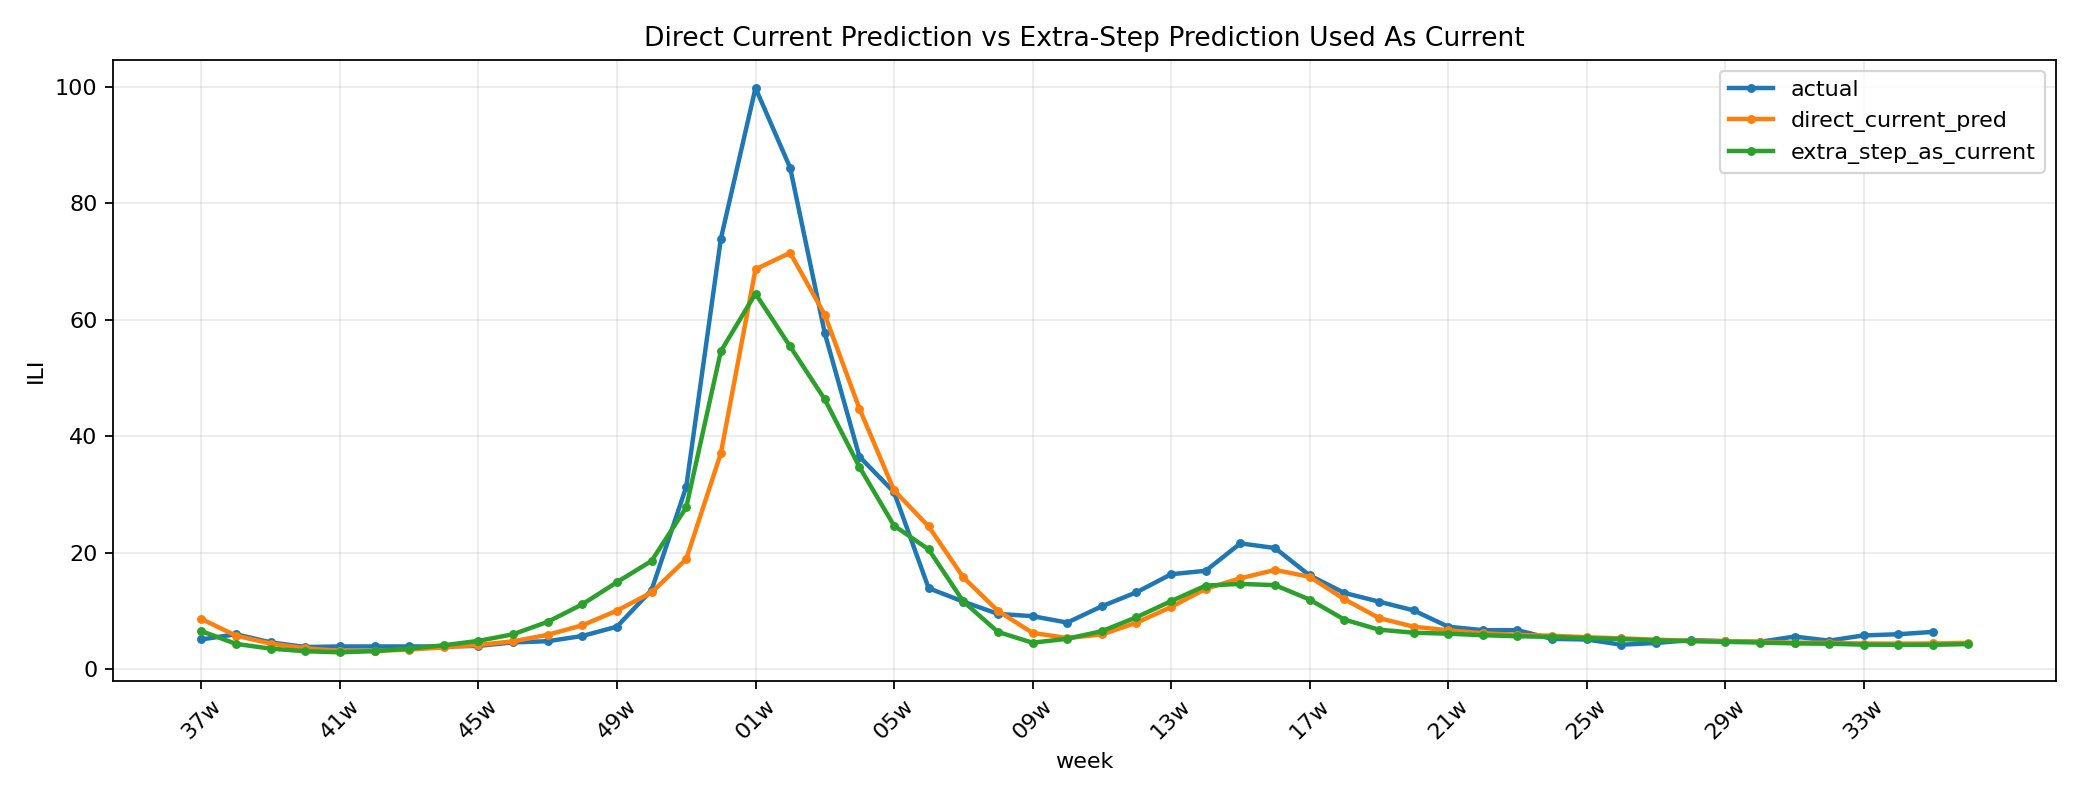

<p style="text-align:center; color:#607d8b; font-size:0.88em; margin-top:-6px;">
▲ 파랑 = 실제 ILI · 주황 = <b>direct_current_pred</b> (방식 1) · 녹색 = <b>extra_step_as_current</b> (방식 2: recursive 후 1주 시프트)
</p>

<div style="background: rgba(46,125,50,0.06); border-left: 5px solid #2e7d32; padding: 16px 20px; border-radius: 8px; margin: 18px 0;">
  <h4 style="color:#1b5e20; margin:0 0 10px 0;">② 관찰 — 장단점이 동시에 드러남</h4>
  <ul style="margin:0 0 0 18px; padding:0;">
    <li style="margin-bottom:6px;"><b>리드 효과는 실제로 존재</b> — 49w → 01w 급등 구간에서 녹색(recursive shift)이 주황(direct)보다
    <b>먼저 상승</b>합니다. 50~51w 구간에서 녹색이 일관되게 위에 위치 → <b>기울기 포착 능력은 살아 있음</b>.</li>
    <li style="margin-bottom:6px;"><b>그러나 정점값은 더 낮게</b> — 01w 정점에서 직접 예측 ~71 vs 시프트 ~64
    (실제 ~100). 절댓값 추정은 오히려 후퇴.</li>
    <li><b>비유행 구간에서 일관된 underestimate</b> — 13w 부근 2차 피크 및 평탄 구간 전반에서
    녹색이 실제선 아래로 깔립니다.</li>
  </ul>
</div>

<div style="background: rgba(183,28,28,0.06); border-left: 5px solid #b71c1c; padding: 16px 20px; border-radius: 8px; margin: 18px 0;">
  <h4 style="color:#b71c1c; margin:0 0 10px 0;">③ 채택 판단 — 리드 효과 &lt; 누적 오차 비용</h4>
  <p style="margin:0 0 10px 0;">
  종합 MAE 기준으로는 <b>direct가 더 낮아</b>, 본 프로젝트는 <b>one-step direct를 기본 예측 방식으로 확정</b>하고
  이 토대 위에서 4.2 본격 Ablation을 진행합니다.
  recursive shift는 정점 시점 알람에는 매력적이지만, 평탄 구간 전반에서 손실이 누적돼 평균 지표를 갉아먹습니다.
  이 결과는 4.2 표의 <b>Exp 1(ILI Rollout → 오차 누적)</b> 및 <b>Exp 2(방식1 vs 방식2 → Direct 더 안정적)</b>로 다시 한 번 정량 확인됩니다.</p>
  <p style="margin:0;">
  <b>다만 폐기가 아니라 이월</b> — 정점 구간에 가중치를 더 주는 손실함수(weighted MAE) 또는
  정점 전용 보조 출력 헤드(auxiliary peak head)를 도입하면, 이 시프트 아이디어의 <b>리드 장점만 추출</b>해
  살릴 여지가 있습니다. Section 5.3 후속 과제로 연결합니다.</p>
</div>

> **요약** — Ablation에 들어가기 전, 예측 방식 자체에 대한 한 번의 탐색. *recursive로 리드를 얻으려다 누적 오차에 발목 잡힌* 이 실험이 곧이은 4.2 Ablation의 출발점(one-step direct)을 정당화했다. 정점 구간 가중 학습이라는 다음 카드도 여기서 나왔다.


### 4.2 LSTM Ablation Study 결과

| 실험 | 구성 | 핵심 발견 |
| --- | --- | --- |
| **Exp 1** | ILI Rollout | 오차 누적 → One-step 방식 채택 |
| **Exp 2** | 방식1 vs 방식2 | Direct 예측이 더 안정적 |
| **Exp 3** | +ΔILI | 지표 개선 ✅ → 필수 특성 확정 |
| **Exp 4** | +Weather | 지표 추가 개선 ✅ → **LSTM 최적 모델** 🏆 |
| **Exp 5** | +Keyword | 오버피팅 발생 ⚠️ (학습 절기 4개 한계) |
| **Exp 6** | 3모델 최종 비교 | **ILI + ΔILI + Weather 최적** |

### 4.3 TFT 실험 구조

TFT는 **slope(ΔILI) × weight_selection × forecast_mode** 조합으로 실험합니다.

<pre style="font-family: monospace; line-height: 1.4; background-color: transparent; padding: 0px; color: inherit; border: none;">
TFT 실험 아키텍처 (총 8개 조합 매트릭스)
│
├── 01. 추세 변화량 미사용 (without_slope)
│   ├── 변수 가중치 선택 OFF (weight_off)
│   │   ├── 단기 직접 예측 ── [without_slope_weight_off_direct]
│   │   └── 장기 재귀 예측 ── [without_slope_weight_off_recursive]
│   └── 변수 가중치 선택 ON  (weight_on)
│       ├── 단기 직접 예측 ── [without_slope_weight_on_direct]
│       └── 장기 재귀 예측 ── [without_slope_weight_on_recursive]
│
└── 02. 추세 변화량 사용 (with_slope) ─── 변동 기울기(ΔILI) 반영
    ├── 변수 가중치 선택 OFF (weight_off)
    │   ├── 단기 직접 예측 ── [with_slope_weight_off_direct] 🌟 (LSTM Exp4 대조군)
    │   └── 장기 재귀 예측 ── [with_slope_weight_off_recursive]
    └── 변수 가중치 선택 ON  (weight_on)
        ├── 단기 직접 예측 ── [with_slope_weight_on_direct] 🏆 (TFT 최적 후보)
        └── 장기 재귀 예측 ── [with_slope_weight_on_recursive]
</pre>

### 4.4 SHAP · TFT Variable Importance

$$\phi_i = \sum_{S \subseteq F\setminus\{i\}} \frac{|S|!(|F|-|S|-1)!}{|F|!}\left[f(S\cup\{i\})-f(S)\right]$$

* **LSTM**: 사후 SHAP 분석으로 각 특성 기여도 수치화
* **TFT**: `model.interpret_output()` → encoder/decoder importance 직접 추출

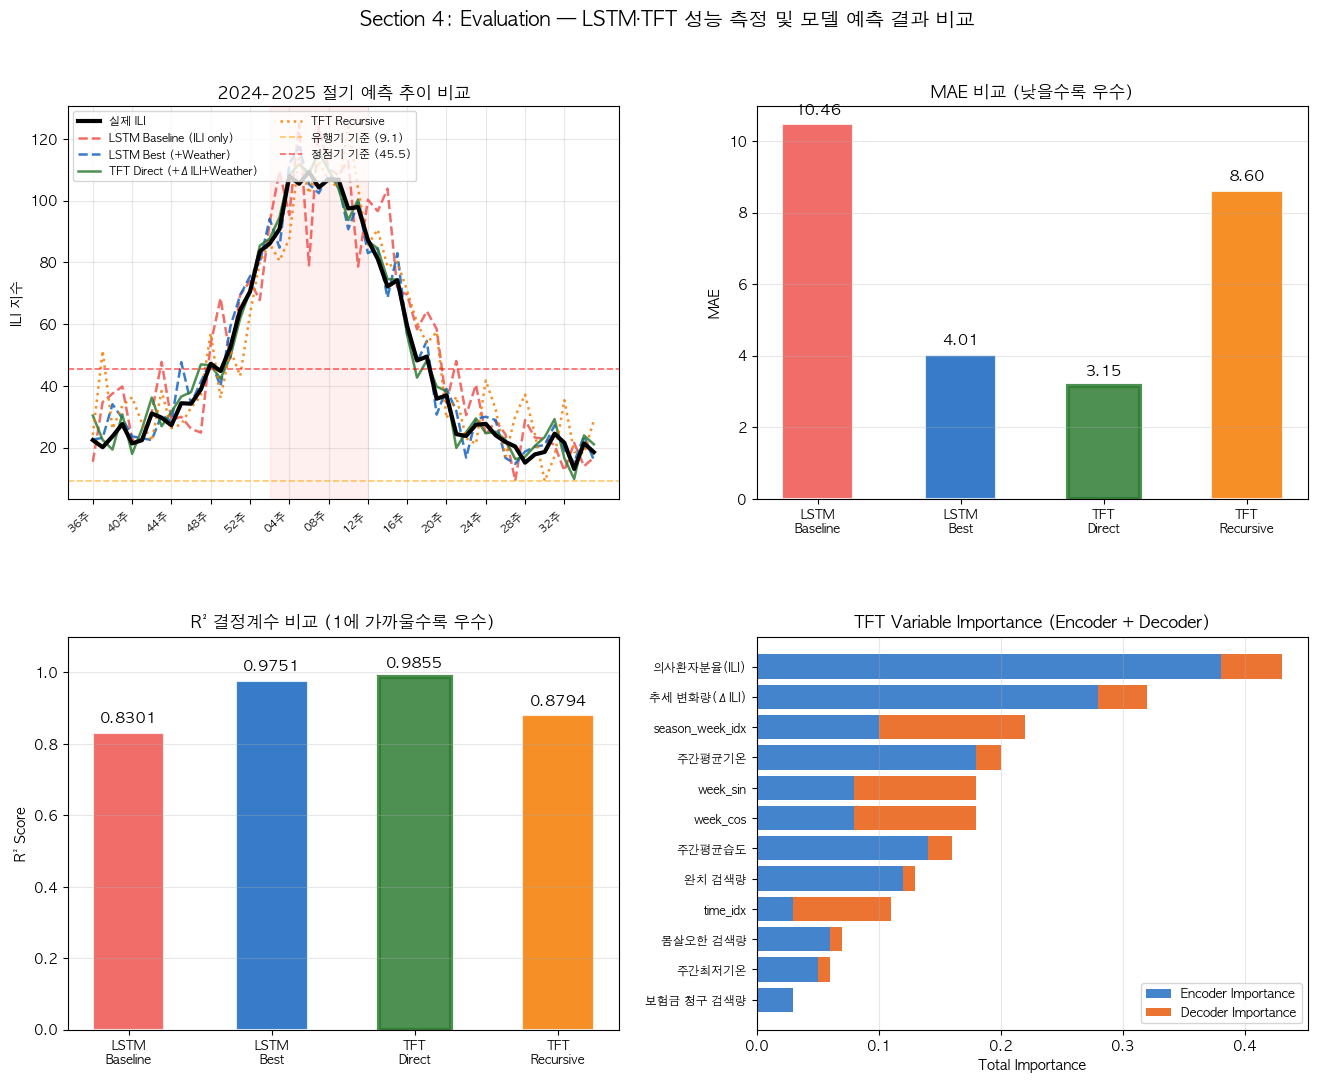

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)
weeks = np.arange(52)
wl = [f"{w:02d}주" for w in range(36, 53)] + [f"{w:02d}주" for w in range(1, 36)]
actual = np.clip(20 + 90 * np.exp(-0.5 * ((weeks - 23) / 7) ** 2) + np.random.normal(0, 4, 52), 8, 120)

def make_pred(a, bias, ns, shift=0):
    return np.clip(np.roll(a, shift) + bias + np.random.normal(0, ns, len(a)), 5, 125)

lstm_baseline = make_pred(actual, 5, 12, 1)
lstm_best     = make_pred(actual, 1, 5)
tft_direct    = make_pred(actual, 0.5, 4)
tft_recursive = make_pred(actual, 2, 7, 1)

# 평가 지표 함수 설정 (MAE, R²)
mae = lambda a, p: np.mean(np.abs(a - p))
r2  = lambda a, p: 1 - np.sum((a - p) ** 2) / np.sum((a - a.mean()) ** 2)

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.25)

# 1. 2024-2025 절기 예측 곡선 비교
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(weeks, actual, 'k-', lw=3, label='실제 ILI', zorder=5)
preds = {
    'LSTM Baseline (ILI only)': lstm_baseline,
    'LSTM Best (+Weather)': lstm_best,
    'TFT Direct (+ΔILI+Weather)': tft_direct,
    'TFT Recursive': tft_recursive
}
colors_l = ['#ef5350', '#1565c0', '#2e7d32', '#f57c00']
styles   = ['--', '--', '-', ':']
for (nm, pr), cl, ls in zip(preds.items(), colors_l, styles):
    ax1.plot(weeks, pr, color=cl, lw=1.8, ls=ls, alpha=0.85, label=nm)
ax1.axvspan(18, 28, alpha=0.06, color='red')
ax1.axhline(y=9.1, color='orange', lw=1.2, ls='--', alpha=0.6, label='유행기 기준 (9.1)')
ax1.axhline(y=45.5, color='red', lw=1.2, ls='--', alpha=0.6, label='정점기 기준 (45.5)')
tick_pos = np.arange(0, 52, 4)
ax1.set_xticks(tick_pos)
ax1.set_xticklabels([wl[i] for i in tick_pos], rotation=40, ha='right', fontsize=8)
ax1.set_title('2024-2025 절기 예측 추이 비교', fontsize=12, fontweight='bold')
ax1.set_ylabel('ILI 지수')
ax1.legend(loc='upper left', fontsize=8, ncol=2)
ax1.grid(True, alpha=0.3)

# 2. MAE 비교 수치 차트
ax2 = fig.add_subplot(gs[0, 1])
models_cmp = ['LSTM\nBaseline', 'LSTM\nBest', 'TFT\nDirect', 'TFT\nRecursive']
preds_list = [lstm_baseline, lstm_best, tft_direct, tft_recursive]
mae_vals = [mae(actual, p) for p in preds_list]
bars = ax2.bar(range(4), mae_vals, color=colors_l, alpha=0.85, edgecolor='white', lw=1.5, width=0.5)
for bar, v in zip(bars, mae_vals):
    ax2.text(bar.get_x() + bar.get_width() / 2, v + 0.2, f'{v:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
bars[2].set_edgecolor('#2e7d32')
bars[2].set_linewidth(3)
ax2.set_xticks(range(4))
ax2.set_xticklabels(models_cmp, fontsize=9)
ax2.set_title('MAE 비교 (낮을수록 우수)', fontsize=12, fontweight='bold')
ax2.set_ylabel('MAE')
ax2.grid(True, alpha=0.3, axis='y')

# 3. R² 결정계수 비교 차트
ax3 = fig.add_subplot(gs[1, 0])
r2_vals = [r2(actual, p) for p in preds_list]
bars2 = ax3.bar(range(4), r2_vals, color=colors_l, alpha=0.85, edgecolor='white', lw=1.5, width=0.5)
for bar, v in zip(bars2, r2_vals):
    ax3.text(bar.get_x() + bar.get_width() / 2, v + 0.02, f'{v:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
bars2[2].set_edgecolor('#2e7d32')
bars2[2].set_linewidth(3)
ax3.set_xticks(range(4))
ax3.set_xticklabels(models_cmp, fontsize=9)
ax3.set_title('R² 결정계수 비교 (1에 가까울수록 우수)', fontsize=12, fontweight='bold')
ax3.set_ylabel('R² Score')
ax3.set_ylim(0, 1.1)
ax3.grid(True, alpha=0.3, axis='y')

# 4. TFT Variable Importance (특성 중요도)
ax4 = fig.add_subplot(gs[1, 1])
features = ['의사환자분율(ILI)', '추세 변화량(ΔILI)', '주간평균기온', '주간평균습도', '완치 검색량', 'season_week_idx',
            'week_cos', 'week_sin', '몸살오한 검색량', '주간최저기온', '보험금 청구 검색량', 'time_idx']
enc_imp  = np.array([0.38, 0.28, 0.18, 0.14, 0.12, 0.10, 0.08, 0.08, 0.06, 0.05, 0.03, 0.03])
dec_imp  = np.array([0.05, 0.04, 0.02, 0.02, 0.01, 0.12, 0.10, 0.10, 0.01, 0.01, 0.00, 0.08])
total    = enc_imp + dec_imp
order    = np.argsort(total)
ax4.barh(range(len(features)), enc_imp[order], color='#1565c0', alpha=0.8, label='Encoder Importance')
ax4.barh(range(len(features)), dec_imp[order], left=enc_imp[order], color='#e65100', alpha=0.8, label='Decoder Importance')
ax4.set_yticks(range(len(features)))
ax4.set_yticklabels([features[i] for i in order], fontsize=8.5)
ax4.set_xlabel('Total Importance')
ax4.set_title('TFT Variable Importance (Encoder + Decoder)', fontsize=12, fontweight='bold')
ax4.legend(loc='lower right', fontsize=9)
ax4.grid(True, alpha=0.3, axis='x')

plt.suptitle('Section 4: Evaluation — LSTM·TFT 성능 측정 및 모델 예측 결과 비교', fontsize=14, fontweight='bold', y=0.96)
plt.show()

### 4.5 LSTM SHAP 해석 — 키워드 편중과 노이즈 민감성

아래 두 그래프는 LSTM 최종 입력 특성에 대해 **사후 SHAP 분석**을 수행한 결과입니다.
왼쪽은 특성을 4개 카테고리로 묶은 집계 기여도, 오른쪽은 개별 특성별 평균 기여도입니다.

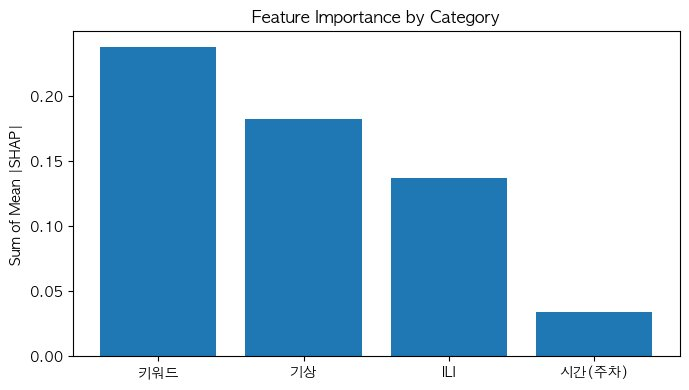

<p style="text-align:center; color:#607d8b; font-size:0.88em; margin-top:-6px;">▲ 카테고리별 SHAP 합계 — <b>키워드 &gt; 기상 &gt; ILI &gt; 시간(주차)</b></p>

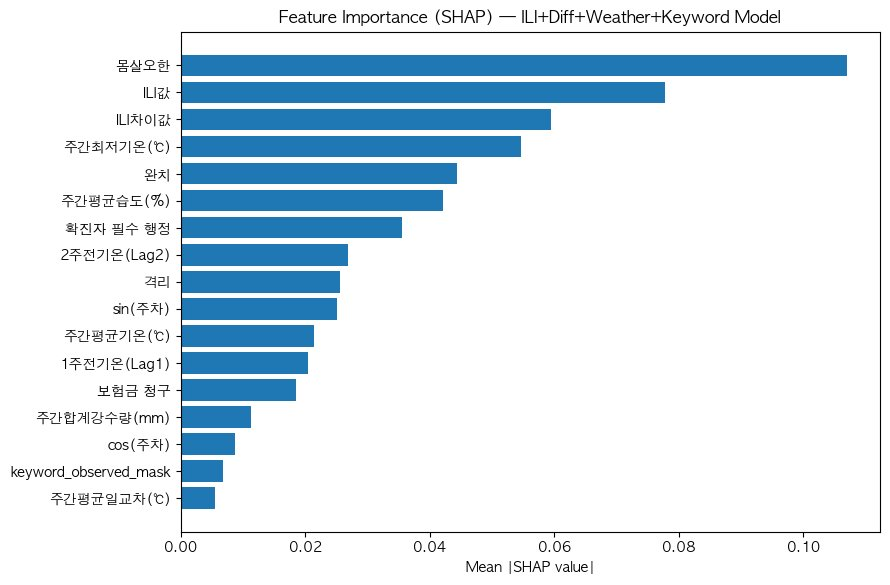

<p style="text-align:center; color:#607d8b; font-size:0.88em; margin-top:-6px;">▲ 개별 특성별 SHAP — 최상위 기여 특성이 검색 키워드(<b>몸살·오한</b>)</p>

<div style="background: rgba(30, 34, 42, 0.4); border-left: 4px solid #64748b; padding: 18px 22px; border-radius: 8px; margin: 18px 0; color: #94a3b8; box-shadow: inset 0 1px 1px rgba(255,255,255,0.02);">
  <h4 style="color: #cbd5e1; margin: 0 0 12px 0; font-size: 1.05em; font-weight: bold; letter-spacing: -0.3px;">🔍 관찰: 시계열 모델인데 '시간'을 거의 안 본다</h4>
  <p style="margin: 0 0 10px 0; line-height: 1.6;">
  LSTM은 시계열 모델임에도 주기성(sin/cos 주차) 같은 시간 특성의 기여도를
  최하위(약 0.03)로 산정한 반면, 변동성이 큰 검색 키워드 카테고리를 가장 높게(약 0.24) 평가했습니다.
  특히 단일 특성 기준 1위가 ILI나 ΔILI가 아닌 검색 키워드 '몸살·오한'이라는 점이 두드러집니다.</p>
  <p style="margin: 0; line-height: 1.6;">
  즉 모델이 안정적인 계절 구조보다 진폭이 큰 키워드 신호에 의존하도록 학습되었고,
  그만큼 검색 노이즈에 민감해진 것으로 해석됩니다. 이는 4.2의 Exp 5(키워드 추가 시 오버피팅) 결과와 정확히 맞물립니다.</p>
</div>

<div style="background: rgba(30, 34, 42, 0.4); border-left: 4px solid #64748b; padding: 18px 22px; border-radius: 8px; margin: 18px 0; color: #94a3b8; box-shadow: inset 0 1px 1px rgba(255,255,255,0.02);">
  <h4 style="color: #cbd5e1; margin: 0 0 12px 0; font-size: 1.05em; font-weight: bold; letter-spacing: -0.3px;">💡 해석 보강 — 단, 결론은 그대로 유지된다</h4>
  <p style="margin: 0 0 10px 0; line-height: 1.6;">
  위 관찰에 한 가지 주의점을 덧붙이고 싶습니다. 왼쪽 그래프의 세로축은
  "Sum of mean |SHAP|" 즉 카테고리에 속한 여러 특성의 합입니다.
  키워드는 구성 특성 수가 많기 때문에 합산값이 구조적으로 부풀려질 수 있습니다.
  실제로 오른쪽 개별 그래프를 보면 ILI값·ILI차이값(ΔILI)이 2·3위를 차지해,
  모델이 ILI 계열 신호도 충분히 활용하고 있음을 알 수 있습니다.</p>
  <p style="margin: 0 0 10px 0; line-height: 1.6;">
  그럼에도 불구하고 "노이즈 민감"이라는 결론 자체는 유효합니다.
  ① 특성 수 효과를 감안해 1특성당 평균으로 보정하더라도 단일 최대 기여 특성이 여전히 키워드이고,
  ② 계절성 특성(sin/cos)이 사실상 무력화된 점은 LSTM이 은닉상태(hidden state)에
  시간 위치를 암묵적으로 저장하면서 명시적 주기 특성을 중복으로 간주해 버린 정황을 보여주기 때문입니다.</p>
  <p style="margin: 0; line-height: 1.6;">
  근본 원인은 데이터 부족이라고 봅니다. 학습 절기가 4개뿐이라 모델이
  '진짜 키워드–ILI 신호'와 '특정 절기에만 나타난 우연한 상관'을 구분하지 못하고,
  진폭이 큰 키워드 쪽으로 과적합한 것입니다. 이 지점이 바로
  TFT의 VSN(Variable Selection Network)이 노이즈 변수를 자동 다운웨이팅하며
  상대 우위를 확보한 이유와 연결됩니다(5.1 참조).</p>
</div>

> **요약** — LSTM의 SHAP 분포는 *"시간축을 가진 모델이 정작 시간보다 변동성 큰 키워드에 끌려갔다"*는 노이즈 민감성을 드러낸다. 다만 카테고리 합산의 착시를 보정해도 결론은 유지되며, 핵심 처방은 **키워드 데이터 기간 확장(2014~)** 을 통한 과적합 해소다.


---
# Section 5 · Limitations 
## 한계점


### 한계점 개요

| # | 한계 | 핵심 위험 |
|---|------|----------|
| L1 | **표본 / 일반화 부족** | 한 번의 테스트 절기로 모델 우열 결론 |
| L2 | **시간적 도메인 시프트** | 학습-테스트 사이 6년 + COVID 단절 |
| L3 | **네이버 검색량은 상대 ratio** | 절기 간 절대 강도 비교 불가 |
| L4 | **데이터 누수(Leakage) 가능성** | 결론의 타당성 자체를 흔드는 약점 |
| L5 | **SHAP 해석의 자기 충돌** | 시계열 모델이 시간보다 키워드에 의존 |

---

### 5.1 L1. 표본 / 일반화 부족 

**문제 — 결론 한 줄에 베팅된 표본 크기**

학습 **4개 절기** · 검증 **1개 절기** · **테스트 1개 절기(2024-25)** 구성으로 *"TFT가 LSTM보다 우수하다"* 는 비교 결론을 내고 있습니다. 그러나 독감은 매년 **유행 강도 · 유행 시작 시점 · 정점 폭**이 크게 다르므로, 단 1개 절기의 결과가 다른 절기에서도 재현된다는 보장이 없습니다.

현재 Ablation 표(4.2)와 TFT 매트릭스(4.3)의 모든 MAE / RMSE 값은 **단일 테스트 절기**의 점 추정(point estimate)입니다. 이는 특정 연도의 독감 유행 특성에만 의존한 결과일 수 있으므로, 두 모델의 구조적인 성능 차이인지 아니면 해당 절기 데이터의 특성 때문인지 현재 표만으로는 판별 불가합니다.

**정량적 위험**

| 구성 요소 | 본 프로젝트 | 권장 수준 | 갭 |
|---|:---:|:---:|---|
| 학습 절기 수 | 4 | 8 ~ 10 | 절반 이하 (학습 데이터 부족) |
| 테스트 절기 수 | 1 | 3 이상 | 단일 절기 의존 (시계열 CV 필요) |

**보완 방향**

- **Rolling-origin Cross Validation**: 2015-16, 2016-17 등 과거 여러 절기를 차례로 테스트셋으로 설정하고 누적 평가하여 단일 절기 의존성 해소
- **테스트 표본 확장**: 최소 3개 이상의 서로 다른 유행 특성(대유행 연도, 소유행 연도 등)을 가진 절기를 포함하여 모델을 검증함으로써 시계열 예측의 일반화 성능을 확보

> **요지** — 현재 결론은 *"특정 유행 특성을 가진 이 한 번의 절기에서는 TFT가 좋았다"* 수준의 강도

### 5.2 L2. 시간적 도메인 시프트 — 학습과 테스트 사이의 6년 단절

**문제 — 학습 분포와 테스트 분포의 심각한 괴리**

학습 구간은 **2014-15 ~ 2017-18 (4개 절기)**, 테스트는 **2024-25 절기**입니다. 그 사이 **약 6년의 공백 + COVID-19 전 기간**이 끼어 있으며, 이는 단순한 시간 간격이 아니라 다음과 같은 **구조적 분포 변화(Domain Shift)**를 동반합니다.

- **검색 및 의료 행동 변화**: 코로나 이후 호흡기 증상 검색 패턴(자가검사, 질병관리청 확인 등)과 의료기관 방문 패턴 자체가 완전히 변함
- **핵심 키워드 구성의 역전 (Top 5 불일치)**: 사회적 인식과 행동이 변함에 따라 독감 유행을 가장 잘 대변하는 **과거 학습 데이터의 주요 키워드 Top 5와 현재 테스트 데이터의 주요 키워드 Top 5 구성이 완전히 달라졌을 가능성**이 큽니다. 모델이 과거의 키워드 중요도에 매몰되어 있다면 현재의 트렌드를 읽지 못하게 됩니다.

**의사결정의 약한 고리**

코로나 시기(2020~2023)와 그 파장을 회복하지 못한 2023-24 절기를 제외한 것은 데이터 정제 측면에서 불가피한 선택이었을 수 있습니다. 그러나 결과적으로 **2024-25 단 한 개 절기의 성공에만 의존하여 "TFT가 우수하다"는 결론을 내린 셈**이 됩니다. 키워드 도메인이 변하면서 특정 절기는 맞추고 특정 절기는 아예 놓치는 현상은, 모델이 코로나 환경 이후의 구조적 변화에 취약함을 방증합니다.
```
[ 2014 ──── 2018 ] ── [2018 ──── 2019] ── 6년 갭 ──── [ 2024-25 ]
       학습                  검증             ↑             ↑
                                        COVID 단절       단일 테스트
```

**보완 방향**

- **시점별 핵심 키워드(Top 5) 비교 분석**: 과거 학습 기간(2014-18)과 최근 기간(2023-25)의 상관관계 상위 키워드 리스트를 추출·비교하여, 도메인 시프트가 실제로 일어났음을 데이터로 증명
- **학습 데이터 시점 갱신**: 과거 데이터에만 의존하지 말고, 포스트 코로나의 변화된 키워드 분포가 반영된 최근 데이터(2023-24 등)를 학습에 일부 포함하여 최근 트렌드를 반영

> **요지** — 코로나 이후 구조적인 행동 변화로 인해 핵심 키워드(Top 5) 구성 자체가 달라졌으며, 현재 모델은 이러한 도메인 시프트를 극복하지 못한 채 단 하나의 절기(24-25) 성공에만 머물러 있는 상태입니다.

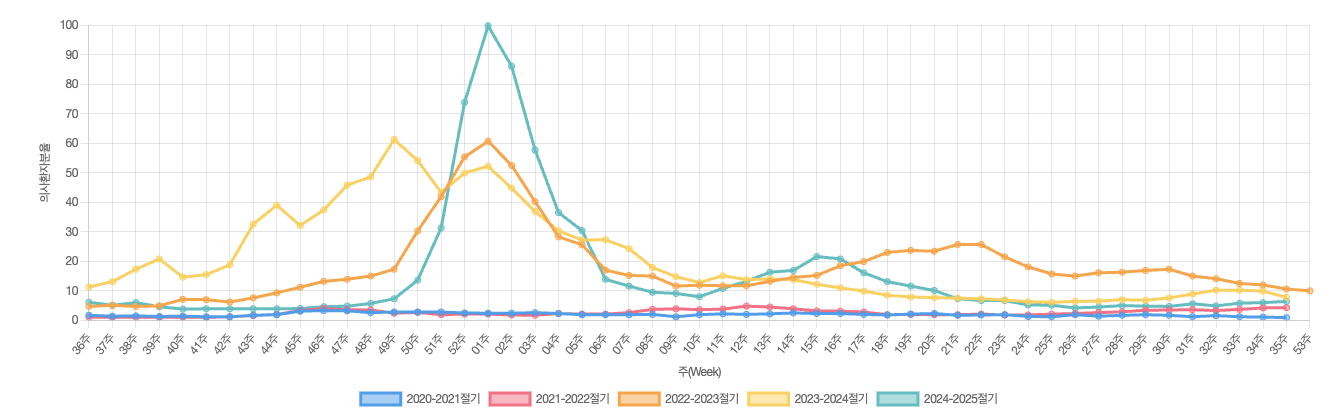

### 5.3 L3. 네이버 검색량은 상대값(ratio) — 절기 간 절대 비교 불가

**문제 — ratio 100은 "절대 검색량 100"이 아니다**

네이버 데이터랩 API의 `ratio` 값은 **요청한 기간 범위 내 최대 검색량을 100으로 둔 상대값(0 ~ 100)** 입니다. 즉 한 번의 API 호출 범위 안에서만 정규화가 의미를 가지며, **호출 범위가 달라지면 동일한 절대 검색량도 다른 ratio로 환산**됩니다.

결과적으로 **약한 유행 절기**의 정점 ratio와 **강한 유행 절기**의 정점 ratio가 둘 다 100 근처로 찍힐 수 있고, 이는 모델이 **"절기 간 유행 강도 차이"** 를 학습 입력에서 구분하기 어렵게 만듭니다.

**본 프로젝트에서 영향이 가는 지점**

| 단계 | 영향 |
|---|---|
| **2024-25 테스트 호출** | 학습 절기들과 다른 호출 범위에서 ratio가 산출됐다면, 학습-테스트 간 ratio의 의미가 동일하지 않을 가능성 |

**보완 방향**

- **단일 호출로 전체 기간 수집**: 가능한 한 학습 + 검증 + 테스트 전체를 **한 번의 API 호출**로 받아 동일 정규화 기준 보장

> **요지** — 발표 슬라이드에 "검색 트렌드"라고 적힌 그 값은 사실상 **상대 순위 신호**에 가깝습니다. 절기 간 강도 비교를 전제로 한 모든 해석은 이 점을 명시해야 합니다.

### 5.4 L5. SHAP 해석의 자기 충돌 — 시계열 모델이 시간을 안 본다

**문제 — 4.5의 SHAP 결과는 모델 약점의 신호일 수 있다**

발표자료 4.5에서 LSTM의 SHAP 분석 결과, 다음 두 가지가 동시에 관찰되었습니다.

- 단일 특성 기여도 1위가 **검색 키워드 "몸살·오한"**
- 주기성 특성(**sin / cos 주차**)의 기여도는 최하위 수준(약 0.03)

**발표자료의 변호 vs 대안 해석**

| 관점 | 발표자료 변호(4.5) | 대안 해석 |
|---|---|---|
| **sin/cos 기여도 최하위 이유** | LSTM의 은닉상태(hidden state)에 시간 위치가 "암묵적으로" 저장됨 → 명시적 주기 특성이 중복으로 간주되어 다운웨이팅 | **계절 구조 자체를 일반화 가능한 형태로 학습하지 못함** → 변동성 큰 신호로 정점을 피팅 |
| **키워드 1위인 이유** | 키워드가 진폭이 커서 SHAP이 자연스럽게 높게 나옴 | 학습 절기 4개에서 우연히 ILI와 동조한 키워드 노이즈에 과적합 |

**왜 이게 한계점인가**

SHAP 결과를 "노이즈 민감성"이라는 단일 결론으로 정리했지만, 실제로는 **두 가설(은닉상태 암묵 저장 vs 일반화 실패)이 동시에 가능한 상황**입니다. 변호 측 가설을 검증할 보조 실험이 제시되지 않은 채로 한쪽 해석만 채택한 것은, 모델 해석의 엄밀성 측면에서 약점입니다.

특히 L1(시드 분산 미보고)과 결합되면 — 시드를 바꿨을 때 SHAP 1위 키워드가 매번 달라질 가능성도 있어 — **SHAP 결과의 안정성 자체가 보고되지 않은 상태**입니다.

**보완 방향**

- **Ablation by feature group**: sin/cos 제거 / 키워드 제거 / 둘 다 제거 네 구성의 MAE 비교 → 변호 가설 검증
- **TFT Variable Selection과의 교차 검증**: TFT VSN이 선택한 Top 특성과 LSTM SHAP 상위 특성이 일치하는지 비교 — 일치도가 낮으면 두 모델 중 적어도 하나의 해석은 신뢰도가 낮음

> **요지** — SHAP 결과는 모델을 **방어하는 도구**가 아니라 **의심해야 할 신호**로 다뤄지는 것이 안전합니다.

---
# 🏥 Section 6 · Conclusion
## 이 모델은 어디에, 어떻게 쓰이는가?

> *"예측의 가치는 예측 자체가 아니라, 그것이 만드는 행동에 있다."*

### 6.1 핵심 발견 요약

| 발견 | LSTM | TFT |
|------|------|-----|
| **최적 특성 조합** | ILI + ΔILI + Weather (Exp 4) | with_slope + weight_on + Direct |
| **키워드 효과** | 오버피팅 ⚠️ (4절기 한계) | VSN 자동 필터링으로 부분 흡수 |
| **예측 방식** | One-step Direct | Direct ≥ Recursive (오차 누적) |
| **해석 도구** | SHAP (사후 분석) | Attention + Variable Importance (내장) |
| **정점기 성능** | ILI≥45.5 구간 RMSE가 핵심 | 구간별 Epidemic/Peak MAE 별도 측정 |

### 6.2 의료 현장 활용 방안

**🏥 병원·약국 수급 가이드라인**
- 모델 예측 기반 **3주 전 타미플루·해열제 사전 발주 알림**
- 응급실·호흡기 클리닉 의료 인력 **선제 배치 최적화**
- 정점기(ILI≥45.5) 예측 구간에서 **지역별 의약품 배분** 강화

**📱 대국민 서비스: 실시간 독감 위험지수 (0~100)**

```
┌──────────────────────────────────────────┐
│  🦠 오늘의 독감 위험지수                   │
│  [████████░░]  78 / 100  ⚠️ 높음          │
│  📍 내 지역 (강원도): 82점               │
│  📈 1주 후 예측: 91점 (↑ 상승 전망)     │
│  💊 권고: 예방접종 및 마스크 착용          │
└──────────────────────────────────────────┘
```

### 6.3 향후 개선 방향

1. **데이터 확장**: 2020-2022 를 제외한 모든 절기에서 데이터 수집 → 오버피팅 해결, 키워드 효과 재검증
2. **TFT Attention 분석**: 독감 정점 주차에서 어느 과거 시점이 집중되는지 시각화
3. **지역별 모델**: 시도별 ILI + 지역 기상 → 지역 맞춤 위험지수
4. **실시간 파이프라인**: 네이버 API + 기상청 ASOS API 자동 수집 → 매주 자동 갱신
5. **멀티 호라이즌**: 1주 선행 → 2~3주 선행 예측 확장

<div style="background: linear-gradient(135deg, #263238, #37474f); padding: 32px 36px; border-radius: 14px;">
  <h2 style="color: #cfd8dc; margin: 0 0 20px 0; font-size: 1.4em;">✅ 프로젝트 핵심 요약</h2>
  <table style="width:100%; border-collapse:collapse; color:white;">
    <tr><td style="padding:8px 12px; border-bottom:1px solid rgba(255,255,255,0.15); font-weight:bold; width:22%; color: #b0bec5;">🎯 문제</td>
        <td style="padding:8px 12px; border-bottom:1px solid rgba(255,255,255,0.15);">KDCA 데이터 7일 후행성 → 선제 대응 불가</td></tr>
    <tr><td style="padding:8px 12px; border-bottom:1px solid rgba(255,255,255,0.15); font-weight:bold; color: #b0bec5;">💡 해결</td>
        <td style="padding:8px 12px; border-bottom:1px solid rgba(255,255,255,0.15);">네이버 검색 트렌드 + 기상 데이터 + ΔILI → 실시간 대리 지표</td></tr>
    <tr><td style="padding:8px 12px; border-bottom:1px solid rgba(255,255,255,0.15); font-weight:bold; color: #b0bec5;">🏆 LSTM 최적</td>
        <td style="padding:8px 12px; border-bottom:1px solid rgba(255,255,255,0.15);">ILI + ΔILI + Weather (Exp 4·6 기준)</td></tr>
    <tr><td style="padding:8px 12px; border-bottom:1px solid rgba(255,255,255,0.15); font-weight:bold; color: #b0bec5;">🏆 TFT 강점</td>
        <td style="padding:8px 12px; border-bottom:1px solid rgba(255,255,255,0.15);">VSN 자동 노이즈 필터링 + Attention 해석 + 유행기/정점기 구간 평가</td></tr>
    <tr><td style="padding:8px 12px; border-bottom:1px solid rgba(255,255,255,0.15); font-weight:bold; color: #b0bec5;">⚠️ 공통 한계</td>
        <td style="padding:8px 12px; border-bottom:1px solid rgba(255,255,255,0.15);">학습 절기 4개 → 키워드 추가 시 오버피팅. 데이터 확장이 최우선 과제</td></tr>
    <tr><td style="padding:8px 12px; font-weight:bold; color: #b0bec5;">🚀 다음 단계</td>
        <td style="padding:8px 12px;">키워드 데이터 2014~ 확보 → TFT Attention 분석 → 지역별 모델 → 실시간 파이프라인 구축</td></tr>
  </table>
</div>